# BATADAL Attack Detection

Random Forest, GDN-inspired, and TGCN-inspired forecasters, evaluated under two protocols:
random row split (literature-comparable) and attack-episode-disjoint split (primary result).

`BATADAL_dataset03.csv` (all-normal) and `BATADAL_dataset04.csv` (7 attack episodes) are used.
`ATT_FLAG` in dataset04 is the official column from the file. The published attack duration
table is used only to build `ATTACK_ID` for splitting and reporting, never to redefine the label.

GDN-inspired and TGCN-inspired reuse the graph-attention and GCN-propagation mechanisms of
Deng and Hooi (2021) and Zhao et al. (2020) respectively. Training loop, windowing, thresholding,
and evaluation protocol are original to this notebook. They are not certified reproductions of
either paper's codebase; this distinction is maintained throughout the write-up.

In [1]:
import itertools
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
                              average_precision_score, precision_recall_curve,
                              classification_report, confusion_matrix)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

WINDOW_SIZE = 24
EPOCHS_DEFAULT = 40
PATIENCE_DEFAULT = 6
LOAO_EPOCHS = 25
LOAO_PATIENCE = 5

print(f"device: {device}")

device: cpu


## 1. Data and labels

In [2]:
df03 = pd.read_csv("BATADAL_dataset03.csv")
df03.columns = df03.columns.str.strip()
df03["DATETIME"] = pd.to_datetime(df03["DATETIME"].str.strip(), format="%d/%m/%y %H")
df03["ATT_FLAG"] = np.where(df03["ATT_FLAG"] == -999, 0, df03["ATT_FLAG"])
df03["ATTACK_ID"] = 0
assert df03["ATT_FLAG"].sum() == 0

df04 = pd.read_csv("BATADAL_dataset04.csv")
df04.columns = df04.columns.str.strip()
df04["DATETIME"] = pd.to_datetime(df04["DATETIME"].str.strip(), format="%d/%m/%y %H")
df04["ATT_FLAG"] = np.where(df04["ATT_FLAG"] == 1, 1, 0)

ATTACK_DURATION_WINDOWS = {
    1: ("2016-09-13 23:00", "2016-09-16 00:00"),
    2: ("2016-09-26 11:00", "2016-09-27 10:00"),
    3: ("2016-10-09 09:00", "2016-10-11 20:00"),
    4: ("2016-10-29 19:00", "2016-11-02 16:00"),
    5: ("2016-11-26 17:00", "2016-11-29 04:00"),
    6: ("2016-12-06 07:00", "2016-12-10 04:00"),
    7: ("2016-12-14 15:00", "2016-12-19 04:00"),
}
df04["ATTACK_ID"] = 0
for attack_id, (start, end) in ATTACK_DURATION_WINDOWS.items():
    df04.loc[(df04["DATETIME"] >= start) & (df04["DATETIME"] <= end), "ATTACK_ID"] = attack_id

FEATURE_COLS = [c for c in df03.columns if c not in ("DATETIME", "ATT_FLAG", "ATTACK_ID")]
combined = pd.concat([df03, df04], ignore_index=True).sort_values("DATETIME").reset_index(drop=True)
y_all = combined["ATT_FLAG"].values
attack_id_all = combined["ATTACK_ID"].values
row_idx = np.arange(len(combined))

print(f"Combined dataset: {combined.shape[0]} rows, {len(FEATURE_COLS)} sensor features")
print(f"Positively labeled attack rows: {y_all.sum()} ({y_all.mean()*100:.2f}%)")
for attack_id in range(1, 8):
    mask = attack_id_all == attack_id
    print(f"  Attack {attack_id}: {y_all[mask].sum()} labeled hours out of {mask.sum()} hours")

Combined dataset: 12938 rows, 43 sensor features
Positively labeled attack rows: 219 (1.69%)
  Attack 1: 42 labeled hours out of 50 hours
  Attack 2: 0 labeled hours out of 24 hours
  Attack 3: 60 labeled hours out of 60 hours
  Attack 4: 37 labeled hours out of 94 hours
  Attack 5: 7 labeled hours out of 60 hours
  Attack 6: 73 labeled hours out of 94 hours
  Attack 7: 0 labeled hours out of 110 hours


## 2. Splits

`random_split` is a stratified row split, matching the protocol used in most tabular BATADAL
literature. `episode_split` trains on attacks 1-3 plus all normal data, tunes the threshold on
attack 4, and tests once on attacks 5-7, with no attack ever appearing in both train and test.

In [3]:
random_tr_idx, random_va_idx = train_test_split(
    row_idx, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE
)

TRAIN_ATTACKS = {1, 2, 3}
VAL_ATTACK = {4}
TEST_ATTACKS = {5, 6, 7}

episode_train_idx = row_idx[np.isin(attack_id_all, list(TRAIN_ATTACKS) + [0])]
episode_val_idx = row_idx[np.isin(attack_id_all, list(VAL_ATTACK))]
episode_test_idx = row_idx[np.isin(attack_id_all, list(TEST_ATTACKS))]

print(f"episode_split train: {len(episode_train_idx)} rows ({y_all[episode_train_idx].sum()} labeled attack hours)")
print(f"episode_split val (attack 4): {len(episode_val_idx)} rows ({y_all[episode_val_idx].sum()} labeled attack hours)")
print(f"episode_split test (attacks 5-7): {len(episode_test_idx)} rows ({y_all[episode_test_idx].sum()} labeled attack hours)")


def loao_splits():
    for held_out in range(1, 8):
        test_idx = row_idx[attack_id_all == held_out]
        train_idx = row_idx[attack_id_all != held_out]
        yield held_out, train_idx, test_idx

episode_split train: 12580 rows (102 labeled attack hours)
episode_split val (attack 4): 94 rows (37 labeled attack hours)
episode_split test (attacks 5-7): 264 rows (80 labeled attack hours)


## 3. Attack overlap

For each attack, the number of hours in train versus eval, under both splits. Under
`random_split` every attack has hours on both sides. Under `episode_split` overlap is zero.

In [4]:
def attack_overlap_table(train_idx, eval_idx, split_name):
    train_set, eval_set = set(train_idx.tolist()), set(eval_idx.tolist())
    print(f"{split_name}")
    print(f"{'Attack ID':>10} | {'Hours in train':>15} | {'Hours in eval':>15} | {'Overlap?':>10}")
    for attack_id in range(1, 8):
        attack_rows = set(row_idx[attack_id_all == attack_id].tolist())
        in_train = len(attack_rows & train_set)
        in_eval = len(attack_rows & eval_set)
        overlap = "YES" if (in_train > 0 and in_eval > 0) else "no"
        print(f"{attack_id:>10} | {in_train:>15} | {in_eval:>15} | {overlap:>10}")
    print()

attack_overlap_table(random_tr_idx, random_va_idx, "random_split (Protocol A)")
attack_overlap_table(episode_train_idx, episode_test_idx, "episode_split (Protocol B, test attacks 5-7)")

random_split (Protocol A)
 Attack ID |  Hours in train |   Hours in eval |   Overlap?
         1 |              37 |              13 |        YES
         2 |              18 |               6 |        YES
         3 |              52 |               8 |        YES
         4 |              75 |              19 |        YES
         5 |              50 |              10 |        YES
         6 |              71 |              23 |        YES
         7 |              91 |              19 |        YES

episode_split (Protocol B, test attacks 5-7)
 Attack ID |  Hours in train |   Hours in eval |   Overlap?
         1 |              50 |               0 |         no
         2 |              24 |               0 |         no
         3 |              60 |               0 |         no
         4 |               0 |               0 |         no
         5 |               0 |              60 |         no
         6 |               0 |              94 |         no
         7 |               0

## 4. Random Forest feature engineering

Cross-sensor residuals are fit on `dataset03` only, so they carry no label information.
Feature selection is refit on the current training partition only, every time it is invoked.

In [5]:
X03 = df03[FEATURE_COLS].values
residual_models = {}
for i, col in enumerate(FEATURE_COLS):
    other_idx = [j for j in range(len(FEATURE_COLS)) if j != i]
    reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
    reg.fit(X03[:, other_idx], X03[:, i])
    residual_models[col] = (reg, other_idx)


def add_residual_features(df, feature_cols, models):
    X = df[feature_cols].values
    resid = np.zeros_like(X, dtype=np.float32)
    for i, col in enumerate(feature_cols):
        model, other_idx = models[col]
        resid[:, i] = X[:, i] - model.predict(X[:, other_idx])
    resid_df = pd.DataFrame(resid, columns=[f"{c}_resid" for c in feature_cols], index=df.index)
    return pd.concat([df, resid_df], axis=1)

combined = add_residual_features(combined, FEATURE_COLS, residual_models)
RESID_COLS = [f"{c}_resid" for c in FEATURE_COLS]
print(f"Trained {len(residual_models)} cross-sensor residual regressors on normal-operation data")

Trained 43 cross-sensor residual regressors on normal-operation data


In [6]:
def add_temporal_features(df, cols, lags=(1, 3), roll=5):
    out = df.copy()
    new_cols = {}
    for col in cols:
        for lag in lags:
            new_cols[f"{col}_lag{lag}"] = out[col].shift(lag)
        new_cols[f"{col}_d1"] = out[col].diff(1)
        new_cols[f"{col}_mean{roll}"] = out[col].rolling(roll).mean()
        new_cols[f"{col}_std{roll}"] = out[col].rolling(roll).std()
    out = pd.concat([out, pd.DataFrame(new_cols, index=out.index)], axis=1)
    return out.ffill().bfill()


def select_features_and_engineer(train_idx_for_selection):
    X_sel = combined.loc[train_idx_for_selection, FEATURE_COLS].values
    y_sel = combined.loc[train_idx_for_selection, "ATT_FLAG"].values
    selector = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    selector.fit(X_sel, y_sel)
    importances = pd.Series(selector.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    top_features = importances.head(10).index.tolist()

    eng = add_temporal_features(combined[["DATETIME", "ATT_FLAG"] + FEATURE_COLS], top_features)
    eng = pd.concat([eng, combined[RESID_COLS]], axis=1)
    eng_cols = [c for c in eng.columns if c not in ("DATETIME", "ATT_FLAG")]
    return eng, eng_cols, top_features

## 5. Protocol A: random split

Within-episode, literature-comparable. Not a generalization measure, since every attack has
hours in both train and validation under this split (Section 3).

In [7]:
eng_a, eng_cols_a, top_features_a = select_features_and_engineer(random_tr_idx)

X_a = eng_a[eng_cols_a].values
X_tr_raw, X_va_raw = X_a[random_tr_idx], X_a[random_va_idx]
y_tr, y_va = y_all[random_tr_idx], y_all[random_va_idx]

scaler_a = StandardScaler()
X_tr = scaler_a.fit_transform(X_tr_raw)
X_va = scaler_a.transform(X_va_raw)

rf_protocol_a = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                        random_state=RANDOM_STATE, n_jobs=-1)
rf_protocol_a.fit(X_tr, y_tr)

preds_a = rf_protocol_a.predict(X_va)
probs_a = rf_protocol_a.predict_proba(X_va)[:, 1]

rf_protocol_a_results = {
    "accuracy": accuracy_score(y_va, preds_a),
    "precision": precision_score(y_va, preds_a, zero_division=0),
    "recall": recall_score(y_va, preds_a, zero_division=0),
    "f1": f1_score(y_va, preds_a, zero_division=0),
    "roc_auc": roc_auc_score(y_va, probs_a),
    "pr_auc": average_precision_score(y_va, probs_a),
}
print("RF Protocol A (random split, within-episode):")
for k, v in rf_protocol_a_results.items():
    print(f"  {k:10s}: {v:.4f}")
print()
print(classification_report(y_va, preds_a, target_names=["Normal", "Attack"]))

RF Protocol A (random split, within-episode):
  accuracy  : 0.9946
  precision : 0.9688
  recall    : 0.7045
  f1        : 0.8158
  roc_auc   : 0.9985
  pr_auc    : 0.9405

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      2544
      Attack       0.97      0.70      0.82        44

    accuracy                           0.99      2588
   macro avg       0.98      0.85      0.91      2588
weighted avg       0.99      0.99      0.99      2588



## 6. Protocol B: attack-disjoint split

Primary result. Train on attacks 1-3 and all normal data, tune the threshold on attack 4,
evaluate once on attacks 5-7. Random Forest is class-weighted rather than SMOTE-balanced, and
hyperparameters are selected via 3-fold cross-validation on the training partition only.

In [8]:
eng_b, eng_cols_b, top_features_b = select_features_and_engineer(episode_train_idx)

X_b = eng_b[eng_cols_b].values
X_train_raw = X_b[episode_train_idx]
y_train = y_all[episode_train_idx]
X_val_raw = X_b[episode_val_idx]
y_val = y_all[episode_val_idx]
X_test_raw = X_b[episode_test_idx]
y_test = y_all[episode_test_idx]

scaler_b = StandardScaler()
X_train = scaler_b.fit_transform(X_train_raw)
X_val = scaler_b.transform(X_val_raw)
X_test = scaler_b.transform(X_test_raw)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [8, 15, None],
    "min_samples_leaf": [1, 3, 5],
}
rf_base = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
grid = GridSearchCV(rf_base, param_grid, scoring="f1", cv=3, n_jobs=-1)
grid.fit(X_train, y_train)
rf_protocol_b = grid.best_estimator_
print("Best params (3-fold CV on training partition only):", grid.best_params_)

val_probs = rf_protocol_b.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)
f1_curve = np.where((precisions + recalls) > 0, 2 * precisions * recalls / (precisions + recalls + 1e-10), 0)
best_threshold = thresholds[np.argmax(f1_curve[:-1])] if len(thresholds) > 0 else 0.5

test_probs = rf_protocol_b.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

rf_protocol_b_results = {
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds, zero_division=0),
    "recall": recall_score(y_test, test_preds, zero_division=0),
    "f1": f1_score(y_test, test_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_probs) if y_test.sum() > 0 else float("nan"),
    "pr_auc": average_precision_score(y_test, test_probs) if y_test.sum() > 0 else float("nan"),
}
print("\nRF Protocol B (attack-disjoint, primary):")
for k, v in rf_protocol_b_results.items():
    print(f"  {k:10s}: {v:.4f}")
print()
print(classification_report(y_test, test_preds, target_names=["Normal", "Attack"]))
print(confusion_matrix(y_test, test_preds))

Best params (3-fold CV on training partition only): {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 400}

RF Protocol B (attack-disjoint, primary):
  accuracy  : 0.5758
  precision : 0.2500
  recall    : 0.2000
  f1        : 0.2222
  roc_auc   : 0.4502
  pr_auc    : 0.2670

              precision    recall  f1-score   support

      Normal       0.68      0.74      0.71       184
      Attack       0.25      0.20      0.22        80

    accuracy                           0.58       264
   macro avg       0.47      0.47      0.47       264
weighted avg       0.55      0.58      0.56       264

[[136  48]
 [ 64  16]]


## 7. Isolation Forest baseline

Trained on normal rows only, same regime as the forecasters in Sections 9-10. This isolates
graph structure as the variable of interest: Random Forest needs attack labels and graph
structure to train, Isolation Forest needs neither, GDN/TGCN need structure but not labels.
Not part of the original proposal's baseline list; added to make the supervised-vs-semi-
supervised comparison fair.

In [9]:
X_train_normal_only = X_train_raw[y_train == 0]
scaler_if = StandardScaler()
X_train_if = scaler_if.fit_transform(X_train_normal_only)
X_val_if = scaler_if.transform(X_val_raw)
X_test_if = scaler_if.transform(X_test_raw)

iso_forest = IsolationForest(n_estimators=300, contamination="auto", random_state=RANDOM_STATE, n_jobs=-1)
iso_forest.fit(X_train_if)

val_scores_if = -iso_forest.score_samples(X_val_if)
test_scores_if = -iso_forest.score_samples(X_test_if)

precisions_if, recalls_if, thresholds_if = precision_recall_curve(y_val, val_scores_if)
f1_curve_if = np.where((precisions_if + recalls_if) > 0,
                        2 * precisions_if * recalls_if / (precisions_if + recalls_if + 1e-10), 0)
best_threshold_if = thresholds_if[np.argmax(f1_curve_if[:-1])] if len(thresholds_if) > 0 else 0.0

test_preds_if = (test_scores_if >= best_threshold_if).astype(int)

iso_forest_results = {
    "accuracy": accuracy_score(y_test, test_preds_if),
    "precision": precision_score(y_test, test_preds_if, zero_division=0),
    "recall": recall_score(y_test, test_preds_if, zero_division=0),
    "f1": f1_score(y_test, test_preds_if, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_scores_if) if y_test.sum() > 0 else float("nan"),
    "pr_auc": average_precision_score(y_test, test_scores_if) if y_test.sum() > 0 else float("nan"),
}
print("Isolation Forest (attack-disjoint, semi-supervised):")
for k, v in iso_forest_results.items():
    print(f"  {k:10s}: {v:.4f}")
print()
print(classification_report(y_test, test_preds_if, target_names=["Normal", "Attack"]))

Isolation Forest (attack-disjoint, semi-supervised):
  accuracy  : 0.4773
  precision : 0.3657
  recall    : 0.9875
  f1        : 0.5338
  roc_auc   : 0.7349
  pr_auc    : 0.5084

              precision    recall  f1-score   support

      Normal       0.98      0.26      0.41       184
      Attack       0.37      0.99      0.53        80

    accuracy                           0.48       264
   macro avg       0.67      0.62      0.47       264
weighted avg       0.79      0.48      0.44       264



## 8. Sensor graphs

Two graphs, both fit on `dataset03` (normal only, no label leakage): top-10 correlation edges
per node, and Granger-causal edges per node capped at the same top-10 density for a fair
comparison. Nodes with no statistically significant causal parent fall back to their top-10
correlation edges.

In [10]:
def build_correlation_edge_index(X, topk=10):
    n = X.shape[1]
    corr = np.nan_to_num(np.corrcoef(X, rowvar=False), nan=0.0)
    np.fill_diagonal(corr, 0.0)
    abs_corr = np.abs(corr)
    src, dst = [], []
    for i in range(n):
        for j in np.argsort(-abs_corr[i])[:topk]:
            src.append(j); dst.append(i)
    return np.array([src, dst], dtype=np.int64)

corr_edge_index_np = build_correlation_edge_index(X03, topk=10)
corr_edge_index = torch.from_numpy(corr_edge_index_np).to(device)
print(f"Correlation graph: {len(FEATURE_COLS)} nodes, {corr_edge_index_np.shape[1]} directed edges")

Correlation graph: 43 nodes, 430 directed edges


In [11]:
GRANGER_MAXLAG = 3
GRANGER_ALPHA = 0.05
GRANGER_TOPK = 10

def build_granger_edge_index(X_normal, maxlag=GRANGER_MAXLAG, alpha=GRANGER_ALPHA, topk=GRANGER_TOPK):
    n = X_normal.shape[1]
    pvals = np.full((n, n), np.nan)
    n_failed = 0
    for i, j in itertools.permutations(range(n), 2):
        try:
            res = grangercausalitytests(X_normal[:, [i, j]], maxlag=maxlag)
            pvals[i, j] = min(res[k][0]["ssr_ftest"][1] for k in range(1, maxlag + 1))
        except Exception:
            n_failed += 1

    corr = np.nan_to_num(np.corrcoef(X_normal, rowvar=False), nan=0.0)
    np.fill_diagonal(corr, 0.0)
    abs_corr = np.abs(corr)

    src, dst, n_fallback = [], [], 0
    for i in range(n):
        row = pvals[:, i].copy()
        row[i] = np.nan
        significant = np.where(row < alpha)[0]
        if len(significant) == 0:
            n_fallback += 1
            chosen = np.argsort(-abs_corr[i])[:topk]
        else:
            chosen = significant[np.argsort(row[significant])][:topk]
        for j in chosen:
            src.append(j); dst.append(i)
    print(f"Granger tests: {n*(n-1)} pairs, {n_failed} undefined (constant-value sources)")
    print(f"Nodes with no significant causal parent (correlation fallback): {n_fallback}/{n}")
    return np.array([src, dst], dtype=np.int64), pvals

granger_edge_index_np, granger_pvals = build_granger_edge_index(X03)
granger_edge_index = torch.from_numpy(granger_edge_index_np).to(device)
print(f"Granger-causal graph: {len(FEATURE_COLS)} nodes, {granger_edge_index_np.shape[1]} directed edges")

Granger tests: 1806 pairs, 546 undefined (constant-value sources)
Nodes with no significant causal parent (correlation fallback): 7/43
Granger-causal graph: 43 nodes, 428 directed edges


## 9. Forecaster windowing

Windows use `WINDOW_SIZE` hours of history to forecast the next hour. Training windows are
drawn from normal rows only, excluding any window whose target falls near the validation or
test attack episodes. Validation windows surround attack 4, test windows surround attacks 5-7.

In [12]:
X_raw_all = combined[FEATURE_COLS].values
n_nodes = X_raw_all.shape[1]


def get_window_ends_for_ids(attack_id_arr, target_ids, window_size, n_rows, surrounding_hours=48):
    valid_ends = np.arange(window_size - 1, n_rows)
    is_target_attack = np.isin(attack_id_arr[valid_ends], list(target_ids))

    target_positions = np.where(np.isin(attack_id_arr, list(target_ids)))[0]
    near_mask = np.zeros(len(valid_ends), dtype=bool)
    if len(target_positions) > 0:
        for pos in target_positions:
            lo, hi = max(0, pos - surrounding_hours), min(n_rows - 1, pos + surrounding_hours)
            near_mask |= (valid_ends >= lo) & (valid_ends <= hi)

    return valid_ends[is_target_attack | (near_mask & (attack_id_arr[valid_ends] == 0))]


def get_normal_training_ends(attack_id_arr, exclude_ids, window_size, n_rows):
    valid_ends = np.arange(window_size - 1, n_rows)
    normal_ends = valid_ends[attack_id_arr[valid_ends] == 0]
    excluded_ends = set(get_window_ends_for_ids(attack_id_arr, exclude_ids, window_size, n_rows).tolist())
    return np.array([e for e in normal_ends if e not in excluded_ends])


gdn_train_ends = get_normal_training_ends(attack_id_all, VAL_ATTACK | TEST_ATTACKS, WINDOW_SIZE, len(X_raw_all))
gdn_val_ends = get_window_ends_for_ids(attack_id_all, VAL_ATTACK, WINDOW_SIZE, len(X_raw_all))
gdn_test_ends = get_window_ends_for_ids(attack_id_all, TEST_ATTACKS, WINDOW_SIZE, len(X_raw_all))

print(f"Training windows (normal only): {len(gdn_train_ends)}")
print(f"Validation windows (attack 4 + surrounding normal): {len(gdn_val_ends)} ({y_all[gdn_val_ends].sum()} labeled attack hours)")
print(f"Test windows (attacks 5-7 + surrounding normal): {len(gdn_test_ends)} ({y_all[gdn_test_ends].sum()} labeled attack hours)")

Training windows (normal only): 12039
Validation windows (attack 4 + surrounding normal): 190 (37 labeled attack hours)
Test windows (attacks 5-7 + surrounding normal): 552 (80 labeled attack hours)


In [13]:
scaler_gdn = StandardScaler()
scaler_gdn.fit(X_raw_all[np.array([e for e in gdn_train_ends])])
X_scaled_gdn = scaler_gdn.transform(X_raw_all).astype(np.float32)

## 10. Models

GDN-inspired: graph attention per timestep, GRU over the window, linear forecast head.
TGCN-inspired: fixed symmetrically-normalized GCN propagation per timestep, same GRU and head.
Both trained with MSE on normal windows only; anomaly score is forecast error.

In [14]:
class ForecastWindowDataset(Dataset):
    def __init__(self, X, end_indices, window_size):
        self.X, self.ends, self.w = X, end_indices, window_size
    def __len__(self):
        return len(self.ends)
    def __getitem__(self, i):
        e = self.ends[i]
        window = self.X[e - self.w + 1: e]
        target = self.X[e]
        return torch.from_numpy(window), torch.from_numpy(target)


class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, edge_index, n_nodes):
        super().__init__()
        self.edge_index, self.n_nodes = edge_index, n_nodes
        self.lin = nn.Linear(in_dim, out_dim)
        self.attn_src = nn.Linear(out_dim, 1, bias=False)
        self.attn_dst = nn.Linear(out_dim, 1, bias=False)

    def forward(self, x):
        h = self.lin(x)
        src, dst = self.edge_index[0], self.edge_index[1]
        e = F.leaky_relu(self.attn_src(h).squeeze(-1)[:, src] + self.attn_dst(h).squeeze(-1)[:, dst])
        e_max = e.max(dim=1, keepdim=True)[0].detach()
        e_exp = torch.exp(e - e_max)
        denom = torch.zeros(x.size(0), self.n_nodes, device=x.device)
        denom.scatter_add_(1, dst.unsqueeze(0).expand(x.size(0), -1), e_exp)
        alpha = e_exp / denom.clamp_min(1e-8)[:, dst]
        out = torch.zeros(x.size(0), self.n_nodes, h.size(-1), device=x.device)
        weighted = h[:, src] * alpha.unsqueeze(-1)
        out.scatter_add_(1, dst.unsqueeze(0).unsqueeze(-1).expand(x.size(0), -1, h.size(-1)), weighted)
        return F.relu(out)


class GDNForecaster(nn.Module):
    def __init__(self, n_nodes, edge_index, hidden_dim=16, gru_hidden=64):
        super().__init__()
        self.n_nodes = n_nodes
        self.gat = GraphAttentionLayer(1, hidden_dim, edge_index, n_nodes)
        self.gru = nn.GRU(input_size=n_nodes * hidden_dim, hidden_size=gru_hidden, batch_first=True)
        self.head = nn.Linear(gru_hidden, n_nodes)

    def forward(self, window):
        B, T, N = window.shape
        x = window.reshape(B * T, N, 1)
        h = self.gat(x).reshape(B, T, -1)
        gru_out, _ = self.gru(h)
        return self.head(gru_out[:, -1, :])

In [15]:
def build_normalized_adjacency(edge_index_np, n_nodes, add_self_loops=True):
    A = np.zeros((n_nodes, n_nodes), dtype=np.float32)
    A[edge_index_np[1], edge_index_np[0]] = 1.0
    if add_self_loops:
        A += np.eye(n_nodes, dtype=np.float32)
    deg = A.sum(axis=1)
    deg_inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    deg_inv_sqrt[deg == 0] = 0.0
    D_inv_sqrt = np.diag(deg_inv_sqrt)
    return torch.from_numpy(D_inv_sqrt @ A @ D_inv_sqrt).to(device)

adj_norm_corr = build_normalized_adjacency(corr_edge_index_np, n_nodes)
adj_norm_granger = build_normalized_adjacency(granger_edge_index_np, n_nodes)


class TGCNForecaster(nn.Module):
    def __init__(self, n_nodes, adj_norm, hidden_dim=16, gru_hidden=64):
        super().__init__()
        self.n_nodes = n_nodes
        self.adj_norm = adj_norm
        self.gcn_lin = nn.Linear(1, hidden_dim)
        self.gru = nn.GRU(input_size=n_nodes * hidden_dim, hidden_size=gru_hidden, batch_first=True)
        self.head = nn.Linear(gru_hidden, n_nodes)

    def forward(self, window):
        B, T, N = window.shape
        x = window.reshape(B * T, N, 1)
        h = self.gcn_lin(x)
        h = torch.einsum("ij,bjd->bid", self.adj_norm, h)
        h = F.relu(h).reshape(B, T, -1)
        gru_out, _ = self.gru(h)
        return self.head(gru_out[:, -1, :])

## 11. Training and evaluation utilities

In [16]:
def train_forecaster(model_cls, model_kwargs, train_ends, val_ends, X_scaled, window_size,
                      epochs=EPOCHS_DEFAULT, patience=PATIENCE_DEFAULT, lr=1e-3, batch_size=64):
    train_ds = ForecastWindowDataset(X_scaled, train_ends, window_size)
    val_ds = ForecastWindowDataset(X_scaled, val_ends, window_size)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = model_cls(**model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    best_val_loss, best_state, no_improve = float("inf"), None, 0
    for epoch in range(epochs):
        model.train()
        for window, target in train_loader:
            window, target = window.to(device), target.to(device)
            optimizer.zero_grad()
            pred = model(window)
            loss = criterion(pred, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for window, target in val_loader:
                pred = model(window.to(device))
                val_losses.append(F.mse_loss(pred, target.to(device), reduction="none").mean(dim=1).cpu().numpy())
        val_loss = np.concatenate(val_losses).mean() if val_losses else float("inf")

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"  epoch {epoch+1}/{epochs} | val forecast MSE {val_loss:.5f}")

        if val_loss < best_val_loss:
            best_val_loss, best_state, no_improve = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model

In [17]:
def compute_window_scores(model, end_indices, X_scaled, window_size, batch_size=256):
    ds = ForecastWindowDataset(X_scaled, end_indices, window_size)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    scores = []
    with torch.no_grad():
        for window, target in loader:
            pred = model(window.to(device))
            mse_per_row = F.mse_loss(pred, target.to(device), reduction="none").mean(dim=1)
            scores.append(mse_per_row.cpu().numpy())
    return np.concatenate(scores)


def point_adjusted_labels_and_preds(y_true, preds, attack_id_arr_subset):
    adjusted_preds = preds.copy()
    for attack_id in np.unique(attack_id_arr_subset):
        if attack_id == 0:
            continue
        mask = attack_id_arr_subset == attack_id
        if y_true[mask].sum() > 0 and preds[mask].sum() > 0:
            adjusted_preds[mask] = y_true[mask]
    return y_true, adjusted_preds


def evaluate_forecaster(model, val_ends, test_ends, X_scaled, y_all, attack_id_all, window_size, label=""):
    val_scores = compute_window_scores(model, val_ends, X_scaled, window_size)
    val_labels = y_all[val_ends]
    threshold_max_val = val_scores.max()

    test_scores = compute_window_scores(model, test_ends, X_scaled, window_size)
    test_labels = y_all[test_ends]
    test_attack_ids = attack_id_all[test_ends]

    preds = (test_scores >= threshold_max_val).astype(int)
    _, adjusted_preds = point_adjusted_labels_and_preds(test_labels, preds, test_attack_ids)

    results = {
        "threshold": threshold_max_val,
        "accuracy": accuracy_score(test_labels, preds),
        "precision": precision_score(test_labels, preds, zero_division=0),
        "recall": recall_score(test_labels, preds, zero_division=0),
        "f1": f1_score(test_labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(test_labels, test_scores) if test_labels.sum() > 0 else float("nan"),
        "pr_auc": average_precision_score(test_labels, test_scores) if test_labels.sum() > 0 else float("nan"),
        "f1_point_adjusted": f1_score(test_labels, adjusted_preds, zero_division=0),
        "precision_point_adjusted": precision_score(test_labels, adjusted_preds, zero_division=0),
        "recall_point_adjusted": recall_score(test_labels, adjusted_preds, zero_division=0),
        "accuracy_point_adjusted": accuracy_score(test_labels, adjusted_preds),
    }

    print(f"[{label}]")
    for k, v in results.items():
        if k != "threshold":
            print(f"  {k:24s}: {v:.4f}")

    print("  Per-attack detection (attacks 5-7):")
    for attack_id in sorted(TEST_ATTACKS):
        mask = test_attack_ids == attack_id
        if mask.sum() == 0:
            continue
        n_labeled = int(test_labels[mask].sum())
        if n_labeled == 0:
            print(f"    Attack {attack_id}: 0 officially labeled hours, detection undefined")
            continue
        detected = bool((preds[mask] & (test_labels[mask] == 1)).any())
        first_flag_idx = np.where(preds[mask] & (test_labels[mask] == 1))[0]
        delay = int(first_flag_idx[0]) if len(first_flag_idx) > 0 and detected else None
        print(f"    Attack {attack_id}: {'DETECTED' if detected else 'MISSED'}"
              f"{f', first correct flag at labeled-hour offset {delay}' if delay is not None else ''}")

    return results, test_scores, test_labels, test_attack_ids

## 12. GDN results

Same windows, splits, and thresholding for both graphs. Any performance difference is
attributable to the graph construction rule.

In [18]:
gdn_corr_forecaster = train_forecaster(
    GDNForecaster, {"n_nodes": n_nodes, "edge_index": corr_edge_index, "hidden_dim": 16, "gru_hidden": 64},
    gdn_train_ends, gdn_val_ends, X_scaled_gdn, WINDOW_SIZE
)
gdn_corr_results, gdn_corr_test_scores, gdn_corr_test_labels, gdn_corr_test_attack_ids = evaluate_forecaster(
    gdn_corr_forecaster, gdn_val_ends, gdn_test_ends, X_scaled_gdn, y_all, attack_id_all, WINDOW_SIZE,
    label="GDN + correlation graph"
)

  epoch 1/40 | val forecast MSE 0.49307
  epoch 6/40 | val forecast MSE 0.39643
  epoch 11/40 | val forecast MSE 0.39483
  early stopping at epoch 14
[GDN + correlation graph]
  accuracy                : 0.9203
  precision               : 0.7143
  recall                  : 0.7500
  f1                      : 0.7317
  roc_auc                 : 0.9591
  pr_auc                  : 0.7008
  f1_point_adjusted       : 0.9877
  precision_point_adjusted: 0.9756
  recall_point_adjusted   : 1.0000
  accuracy_point_adjusted : 0.9964
  Per-attack detection (attacks 5-7):
    Attack 5: MISSED
    Attack 6: DETECTED, first correct flag at labeled-hour offset 14
    Attack 7: 0 officially labeled hours, detection undefined


In [19]:
gdn_granger_forecaster = train_forecaster(
    GDNForecaster, {"n_nodes": n_nodes, "edge_index": granger_edge_index, "hidden_dim": 16, "gru_hidden": 64},
    gdn_train_ends, gdn_val_ends, X_scaled_gdn, WINDOW_SIZE
)
gdn_granger_results, gdn_granger_test_scores, gdn_granger_test_labels, gdn_granger_test_attack_ids = evaluate_forecaster(
    gdn_granger_forecaster, gdn_val_ends, gdn_test_ends, X_scaled_gdn, y_all, attack_id_all, WINDOW_SIZE,
    label="GDN + Granger-causal graph"
)

  epoch 1/40 | val forecast MSE 0.43220
  epoch 6/40 | val forecast MSE 0.38455
  epoch 11/40 | val forecast MSE 0.35887
  epoch 16/40 | val forecast MSE 0.35416
  epoch 21/40 | val forecast MSE 0.34476
  epoch 26/40 | val forecast MSE 0.33279
  epoch 31/40 | val forecast MSE 0.34755
  early stopping at epoch 32
[GDN + Granger-causal graph]
  accuracy                : 0.9330
  precision               : 0.7363
  recall                  : 0.8375
  f1                      : 0.7836
  roc_auc                 : 0.9627
  pr_auc                  : 0.6975
  f1_point_adjusted       : 0.9877
  precision_point_adjusted: 0.9756
  recall_point_adjusted   : 1.0000
  accuracy_point_adjusted : 0.9964
  Per-attack detection (attacks 5-7):
    Attack 5: MISSED
    Attack 6: DETECTED, first correct flag at labeled-hour offset 14
    Attack 7: 0 officially labeled hours, detection undefined


## 13. TGCN results

In [20]:
tgcn_corr_forecaster = train_forecaster(
    TGCNForecaster, {"n_nodes": n_nodes, "adj_norm": adj_norm_corr, "hidden_dim": 16, "gru_hidden": 64},
    gdn_train_ends, gdn_val_ends, X_scaled_gdn, WINDOW_SIZE
)
tgcn_corr_results, tgcn_corr_test_scores, tgcn_corr_test_labels, tgcn_corr_test_attack_ids = evaluate_forecaster(
    tgcn_corr_forecaster, gdn_val_ends, gdn_test_ends, X_scaled_gdn, y_all, attack_id_all, WINDOW_SIZE,
    label="TGCN + correlation graph"
)

  epoch 1/40 | val forecast MSE 0.43904
  epoch 6/40 | val forecast MSE 0.39651
  epoch 11/40 | val forecast MSE 0.39273
  epoch 16/40 | val forecast MSE 0.39923
  early stopping at epoch 19
[TGCN + correlation graph]
  accuracy                : 0.9239
  precision               : 0.6979
  recall                  : 0.8375
  f1                      : 0.7614
  roc_auc                 : 0.9589
  pr_auc                  : 0.7040
  f1_point_adjusted       : 0.9816
  precision_point_adjusted: 0.9639
  recall_point_adjusted   : 1.0000
  accuracy_point_adjusted : 0.9946
  Per-attack detection (attacks 5-7):
    Attack 5: MISSED
    Attack 6: DETECTED, first correct flag at labeled-hour offset 14
    Attack 7: 0 officially labeled hours, detection undefined


In [21]:
tgcn_granger_forecaster = train_forecaster(
    TGCNForecaster, {"n_nodes": n_nodes, "adj_norm": adj_norm_granger, "hidden_dim": 16, "gru_hidden": 64},
    gdn_train_ends, gdn_val_ends, X_scaled_gdn, WINDOW_SIZE
)
tgcn_granger_results, tgcn_granger_test_scores, tgcn_granger_test_labels, tgcn_granger_test_attack_ids = evaluate_forecaster(
    tgcn_granger_forecaster, gdn_val_ends, gdn_test_ends, X_scaled_gdn, y_all, attack_id_all, WINDOW_SIZE,
    label="TGCN + Granger-causal graph"
)

  epoch 1/40 | val forecast MSE 0.43105
  epoch 6/40 | val forecast MSE 0.34258
  epoch 11/40 | val forecast MSE 0.33225
  early stopping at epoch 14
[TGCN + Granger-causal graph]
  accuracy                : 0.9312
  precision               : 0.7333
  recall                  : 0.8250
  f1                      : 0.7765
  roc_auc                 : 0.9659
  pr_auc                  : 0.7280
  f1_point_adjusted       : 0.9877
  precision_point_adjusted: 0.9756
  recall_point_adjusted   : 1.0000
  accuracy_point_adjusted : 0.9964
  Per-attack detection (attacks 5-7):
    Attack 5: MISSED
    Attack 6: DETECTED, first correct flag at labeled-hour offset 14
    Attack 7: 0 officially labeled hours, detection undefined


## 14. Summary

In [22]:
final_summary_rows = []
final_summary_rows.append({
    "Model": "Random Forest", "Graph": "-", "Protocol": "A (random split)",
    "Accuracy": rf_protocol_a_results["accuracy"],
    "F1": rf_protocol_a_results["f1"], "ROC-AUC": rf_protocol_a_results["roc_auc"],
    "PR-AUC": rf_protocol_a_results["pr_auc"],
})
final_summary_rows.append({
    "Model": "Random Forest", "Graph": "-", "Protocol": "B (attack-disjoint)",
    "Accuracy": rf_protocol_b_results["accuracy"],
    "F1": rf_protocol_b_results["f1"], "ROC-AUC": rf_protocol_b_results["roc_auc"],
    "PR-AUC": rf_protocol_b_results["pr_auc"],
})
final_summary_rows.append({
    "Model": "Isolation Forest", "Graph": "-", "Protocol": "B (attack-disjoint)",
    "Accuracy": iso_forest_results["accuracy"],
    "F1": iso_forest_results["f1"], "ROC-AUC": iso_forest_results["roc_auc"],
    "PR-AUC": iso_forest_results["pr_auc"],
})

model_configs = [
    ("GDN", "Correlation", gdn_corr_results),
    ("GDN", "Granger-causal", gdn_granger_results),
    ("TGCN", "Correlation", tgcn_corr_results),
    ("TGCN", "Granger-causal", tgcn_granger_results),
]

for model_name, graph_name, res in model_configs:
    final_summary_rows.append({
        "Model": model_name, "Graph": graph_name, "Protocol": "B (attack-disjoint)",
        "Accuracy": res["accuracy"],
        "F1": res["f1"], "ROC-AUC": res["roc_auc"], "PR-AUC": res["pr_auc"],
    })

final_df = pd.DataFrame(final_summary_rows)
for col in ["Accuracy", "F1", "ROC-AUC", "PR-AUC"]:
    final_df[col] = final_df[col].apply(lambda v: f"{v:.4f}" if isinstance(v, float) else v)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(final_df.to_string(index=False))

           Model          Graph            Protocol Accuracy     F1 ROC-AUC PR-AUC
   Random Forest              -    A (random split)   0.9946 0.8158  0.9985 0.9405
   Random Forest              - B (attack-disjoint)   0.5758 0.2222  0.4502 0.2670
Isolation Forest              - B (attack-disjoint)   0.4773 0.5338  0.7349 0.5084
             GDN    Correlation B (attack-disjoint)   0.9203 0.7317  0.9591 0.7008
             GDN Granger-causal B (attack-disjoint)   0.9330 0.7836  0.9627 0.6975
            TGCN    Correlation B (attack-disjoint)   0.9239 0.7614  0.9589 0.7040
            TGCN Granger-causal B (attack-disjoint)   0.9312 0.7765  0.9659 0.7280


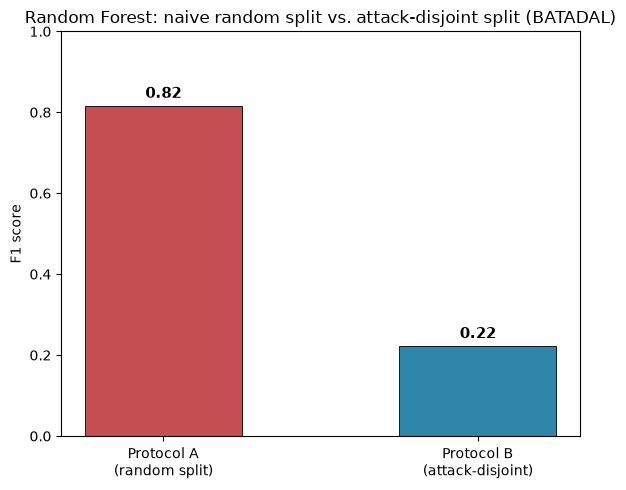

In [23]:
import matplotlib.pyplot as plt

protocols = ["Protocol A\n(random split)", "Protocol B\n(attack-disjoint)"]
f1_vals = [rf_protocol_a_results["f1"], rf_protocol_b_results["f1"]]
colors = ["#C44E52", "#2E86AB"]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(protocols, f1_vals, color=colors, edgecolor="black", linewidth=0.6, width=0.5)
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.0)
ax.set_title("Random Forest: naive random split vs. attack-disjoint split (BATADAL)")
plt.tight_layout()
plt.savefig("fig4_2_batadal_protocol_a_vs_b.png", dpi=150, bbox_inches="tight")
plt.show()

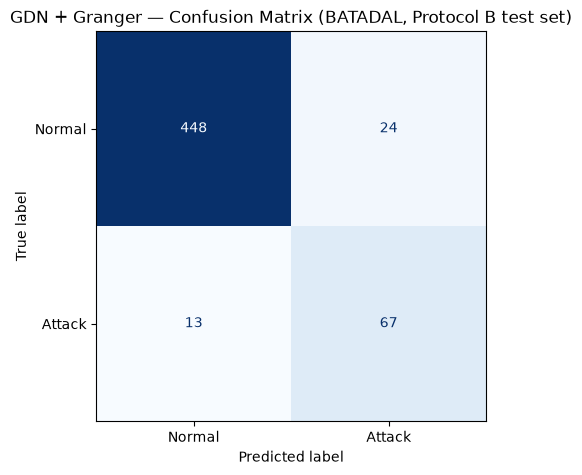

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_best = (gdn_granger_test_scores >= threshold).astype(int)
cm = confusion_matrix(gdn_granger_test_labels, preds_best)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Attack"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("GDN + Granger — Confusion Matrix (BATADAL, Protocol B test set)")
plt.tight_layout()
plt.savefig("fig4_4_batadal_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

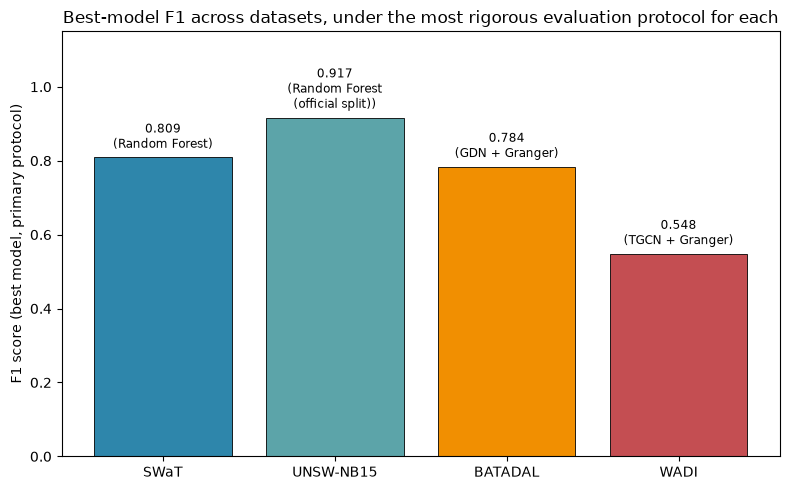

In [27]:
import matplotlib.pyplot as plt

datasets = ["SWaT", "UNSW-NB15", "BATADAL", "WADI"]
best_model = ["Random Forest", "Random Forest\n(official split)", "GDN + Granger", "TGCN + Granger"]
f1_scores = [0.809, 0.9167, 0.7836, 0.548] 
colors = ["#2E86AB", "#5CA4A9", "#F18F01", "#C44E52"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(datasets, f1_scores, color=colors, edgecolor="black", linewidth=0.6)

for bar, model, score in zip(bars, best_model, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f"{score:.3f}\n({model})", ha="center", va="bottom", fontsize=8.5)

ax.set_ylabel("F1 score (best model, primary protocol)")
ax.set_ylim(0, 1.15)
ax.set_title("Best-model F1 across datasets, under the most rigorous evaluation protocol for each")
plt.tight_layout()
plt.savefig("fig_ranked_f1_cross_dataset.png", dpi=150, bbox_inches="tight")
plt.show()